

## Objective

Compare the fastest valid laps of two drivers using FastF1 telemetry data.



In [1]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os
import sys
project_root=os.path.abspath("..")
sys.path.insert(0,project_root)


In [3]:
from src.data.fastf1_loader import load_session

session = load_session(
    2024,
    "British Grand Prix",
    "R",
)

core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 10)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['44', '1', '4', '81', '55', '27', '18', '14', '23', '22', '2', '20', '3', '1

In [4]:
ver=session.laps.pick_driver("VER")
lec=session.laps.pick_driver("LEC")

c:\Users\mehra\OneDrive\Desktop\RaceIntel\venv\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


In [5]:
ver_fast = ver.pick_accurate().pick_fastest()
lec_fast = lec.pick_accurate().pick_fastest()

In [6]:
print(ver_fast)
print(lec_fast)

Time                      0 days 02:14:46.890000
Driver                                       VER
DriverNumber                                   1
LapTime                   0 days 00:01:28.952000
LapNumber                                   48.0
Stint                                        3.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:28.807000
Sector2Time               0 days 00:00:36.166000
Sector3Time               0 days 00:00:23.979000
Sector1SessionTime        0 days 02:13:46.800000
Sector2SessionTime        0 days 02:14:22.966000
Sector3SessionTime        0 days 02:14:46.945000
SpeedI1                                    316.0
SpeedI2                                    266.0
SpeedFL                                    250.0
SpeedST                                    327.0
IsPersonalBest                              True
Compound                                    HARD
TyreLife            

In [7]:
ver_tel = ver_fast.get_car_data().add_distance()

lec_tel = lec_fast.get_car_data().add_distance()

In [8]:
ver_tel.head()

,Date,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Time,SessionTime,Distance
0,2024-07-07 15:18:15.075,11662.0,259.0,6,100.0,False,0,car,0 days 00:00:00.108000,0 days 02:13:18.046000,7.770000
1,2024-07-07 15:18:15.434,10629.0,265.0,6,100.0,False,0,car,0 days 00:00:00.467000,0 days 02:13:18.405000,34.196389
2,2024-07-07 15:18:15.754,10787.0,270.0,7,100.0,False,0,car,0 days 00:00:00.787000,0 days 02:13:18.725000,58.196389
3,2024-07-07 15:18:16.034,10900.0,273.0,7,100.0,False,0,car,0 days 00:00:01.067000,0 days 02:13:19.005000,79.429722
4,2024-07-07 15:18:16.474,11132.0,278.0,7,100.0,False,0,car,0 days 00:00:01.507000,0 days 02:13:19.445000,113.407500


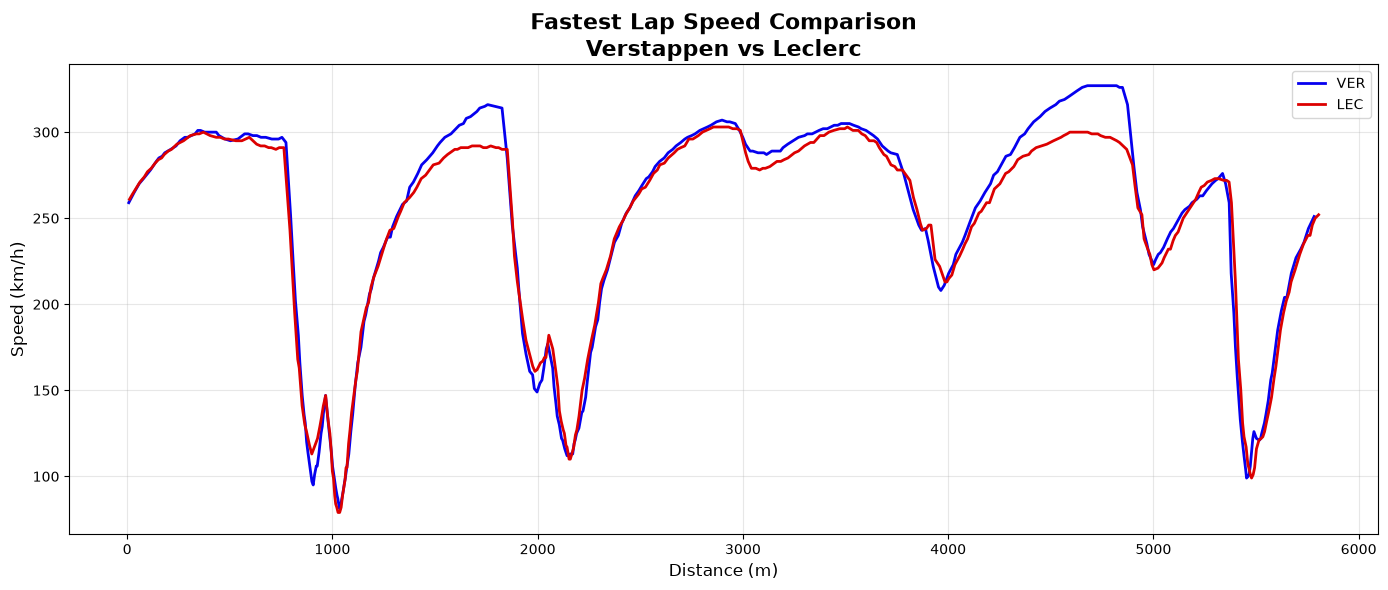

In [9]:
plt.figure(figsize=(14,6))
plt.plot(
    ver_tel["Distance"],
    ver_tel["Speed"],
    label="VER",
    linewidth=2,
    color="#0600EF"      # Red Bull Blue
)
plt.plot(
    lec_tel["Distance"],
    lec_tel["Speed"],
    label="LEC",
    linewidth=2,
    color="#DC0000"      # Ferrari Red
)

plt.title(
    "Fastest Lap Speed Comparison\nVerstappen vs Leclerc",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Distance (m)", fontsize=12)
plt.ylabel("Speed (km/h)", fontsize=12)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

# Save Figure
plt.savefig(
    "../docs/phase_01/screenshots/telemetry_speed_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

- Both drivers reach similar top speeds on the straights.
- Differences in the curves indicate variations in acceleration and braking points.
- This visualization is descriptive only and does not, by itself, explain why one lap was faster.

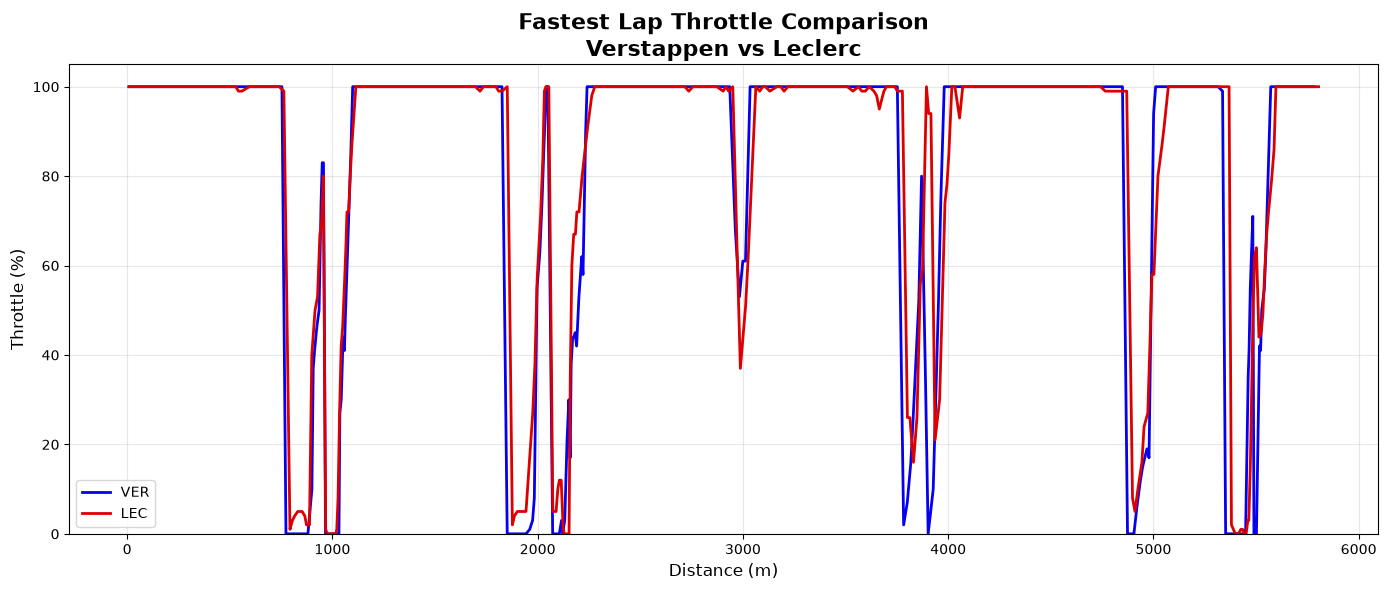

In [10]:
plt.figure(figsize=(14,6))
plt.plot(
    ver_tel["Distance"],
    ver_tel["Throttle"],
    label="VER",
    linewidth=2,
    color="#0600EF"      # Red Bull Blue
)

plt.plot(
    lec_tel["Distance"],
    lec_tel["Throttle"],
    label="LEC",
    linewidth=2,
    color="#DC0000"      # Ferrari Red
)

plt.title(
    "Fastest Lap Throttle Comparison\nVerstappen vs Leclerc",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Distance (m)", fontsize=12)
plt.ylabel("Throttle (%)", fontsize=12)

plt.ylim(0, 105)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "../docs/phase_01/screenshots/telemetry_throttle_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- The graph shows throttle application throughout the fastest lap.
- Periods of full throttle indicate acceleration zones.
- Drops in throttle generally occur before or during cornering.
- Differences between drivers may indicate different throttle application strategies but should not be interpreted as superior driving without further evidence.

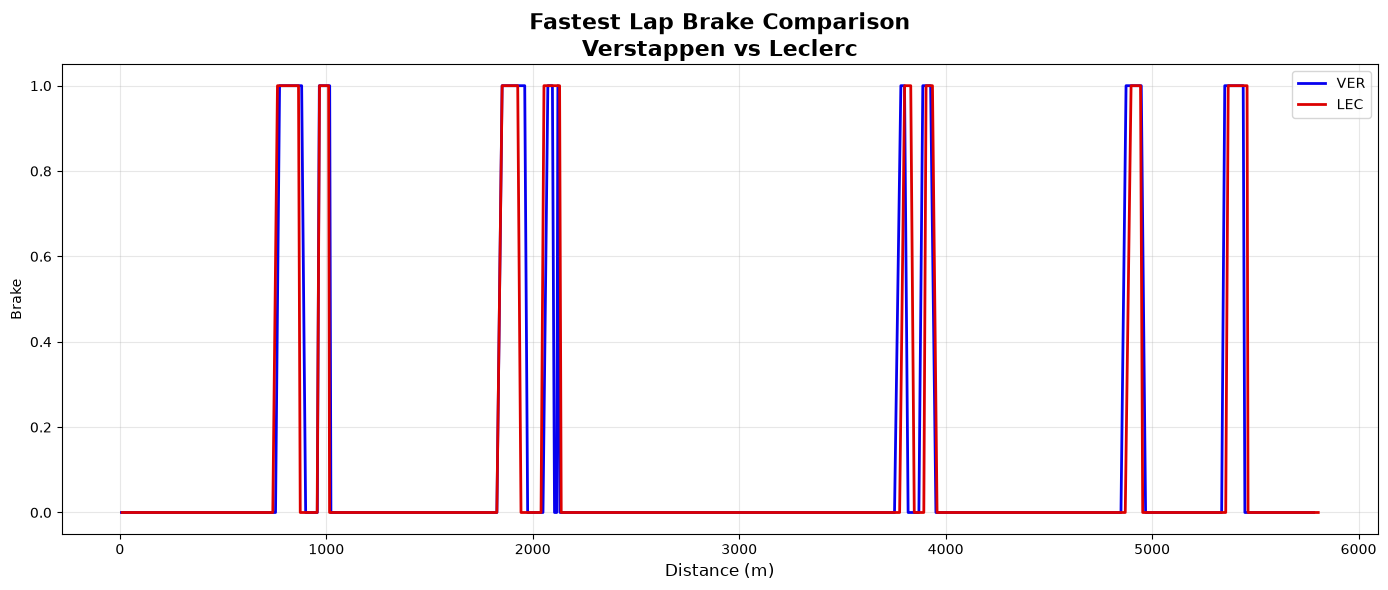

In [11]:
plt.figure(figsize=(14,6))

plt.plot(
    ver_tel["Distance"],
    ver_tel["Brake"],
    label="VER",
    linewidth=2,
    color="#0600EF"
)

plt.plot(
    lec_tel["Distance"],
    lec_tel["Brake"],
    label="LEC",
    linewidth=2,
    color="#DC0000"
)

plt.title(
    "Fastest Lap Brake Comparison\nVerstappen vs Leclerc",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Distance (m)", fontsize=12)
plt.ylabel("Brake")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "../docs/phase_01/screenshots/telemetry_brake_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Brake telemetry indicates where each driver applies braking during the lap.
- Peaks correspond to braking zones before corners.
- Differences in braking points and duration can be observed but should be interpreted alongside speed and throttle data.